In [1]:
import uproot
import hist
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np

plt.style.use(hep.styles.CMS)

In [3]:
histos_zp_G = uproot.open("histograms/v1p2/histograms_zp_G.root")
histos_dy_G = uproot.open("histograms/v1p2/histograms_dy_G.root")

histos_zp_C = uproot.open("histograms/v1p2/histograms_zp_C.root")
histos_dy_C = uproot.open("histograms/v1p2/histograms_dy_C.root")


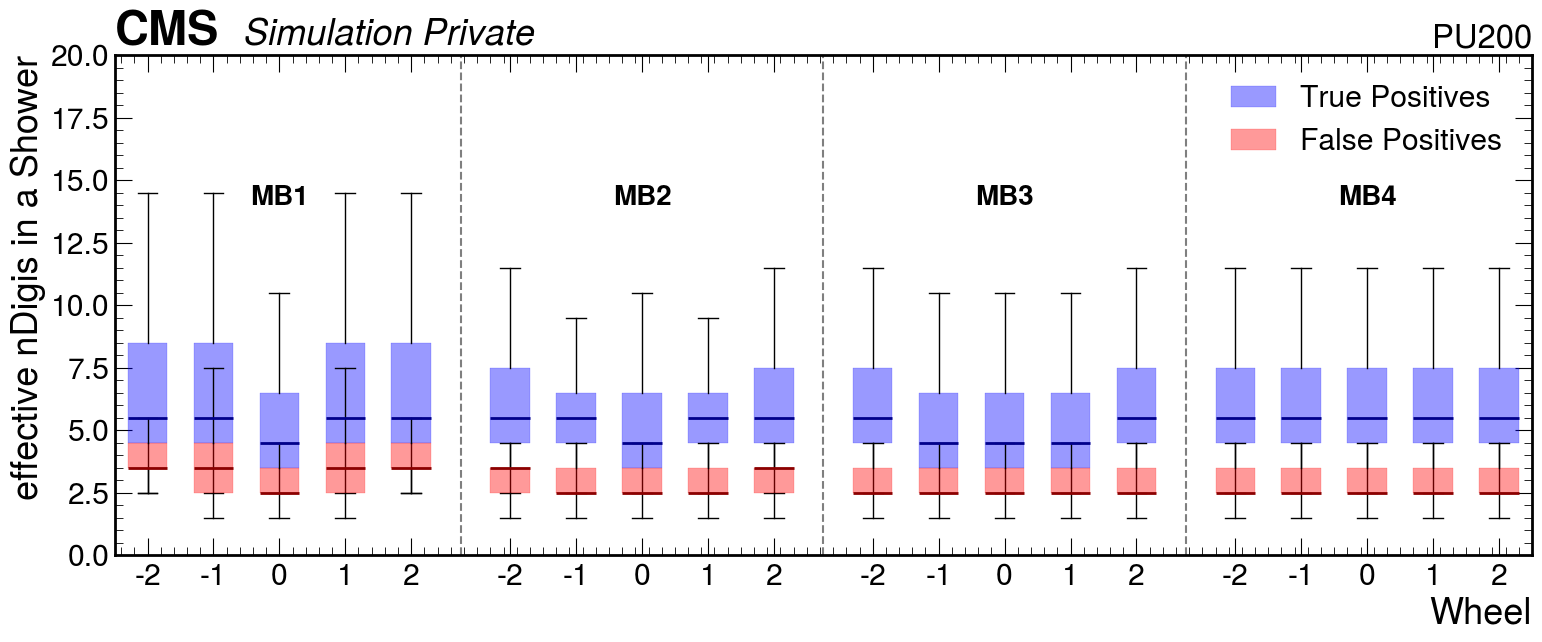

In [4]:
stations = [1, 2, 3, 4]
wheels = [-2, -1, 0, 1, 2]

tp_data = []
fp_data = []
tick_positions = []
tick_labels = []

# 1. Collect data
current_pos = 0
for st in stations:
    for wh in wheels:
        key_tp = f"showers_nDigis_{wh}_{st}_tp;1"
        key_fp = f"showers_nDigis_{wh}_{st}_fp;1"
        
        def get_raw(key):
            if key in histos_zp_G:
                h = histos_zp_G[key].to_hist()
                return np.repeat(h.axes[0].centers, h.values().astype(int))
            return np.array([])

        tp_data.append(get_raw(key_tp))
        fp_data.append(get_raw(key_fp))
        
        tick_positions.append(current_pos)
        tick_labels.append(f"{wh}")
        current_pos += 1
    current_pos += 0.5 

# 2. Plotting
fig, ax = plt.subplots(figsize=(16, 7))

# Plot TP (Blue) and FP (Red) on the exact same positions
# Using alpha=0.5 so the overlap is visible
tp_boxes = ax.boxplot(tp_data, positions=tick_positions, widths=0.6, 
                      patch_artist=True, showfliers=False, label="True Positives")
fp_boxes = ax.boxplot(fp_data, positions=tick_positions, widths=0.6, 
                      patch_artist=True, showfliers=False, label="False Positives")

# 3. Styling - Overlapping with Alpha
for box in tp_boxes['boxes']:
    box.set(facecolor="blue", alpha=0.4, edgecolor="b", linewidth=0.3)
for box in fp_boxes['boxes']:
    box.set(facecolor="red", alpha=0.4, edgecolor="r", linewidth=0.3)

# Keep medians solid so they stand out through the alpha
plt.setp(tp_boxes['medians'], color='darkblue', lw=2)
plt.setp(fp_boxes['medians'], color='darkred', lw=2)

# 4. Axes, Labels and CMS style
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("effective nDigis in a Shower")
ax.set_xlabel("Wheel")
ax.set_ylim(0, 20)

# Station Labels
for i, st in enumerate(stations):
    center = (i * 5.5) + 2
    ax.text(center, ax.get_ylim()[0] + (ax.get_ylim()[1]*0.7), f"MB{st}", 
            ha='center', fontsize=20, fontweight='bold')
    if i < len(stations) - 1:
        ax.axvline((i * 5.5) + 4.75, color="black", linestyle="--", alpha=0.5)

ax.legend(loc='upper right') #handles=legend_elements, 

hep.cms.label(ax=ax, text="Private", data=False, rlabel="PU200")
plt.tight_layout()
plt.show()

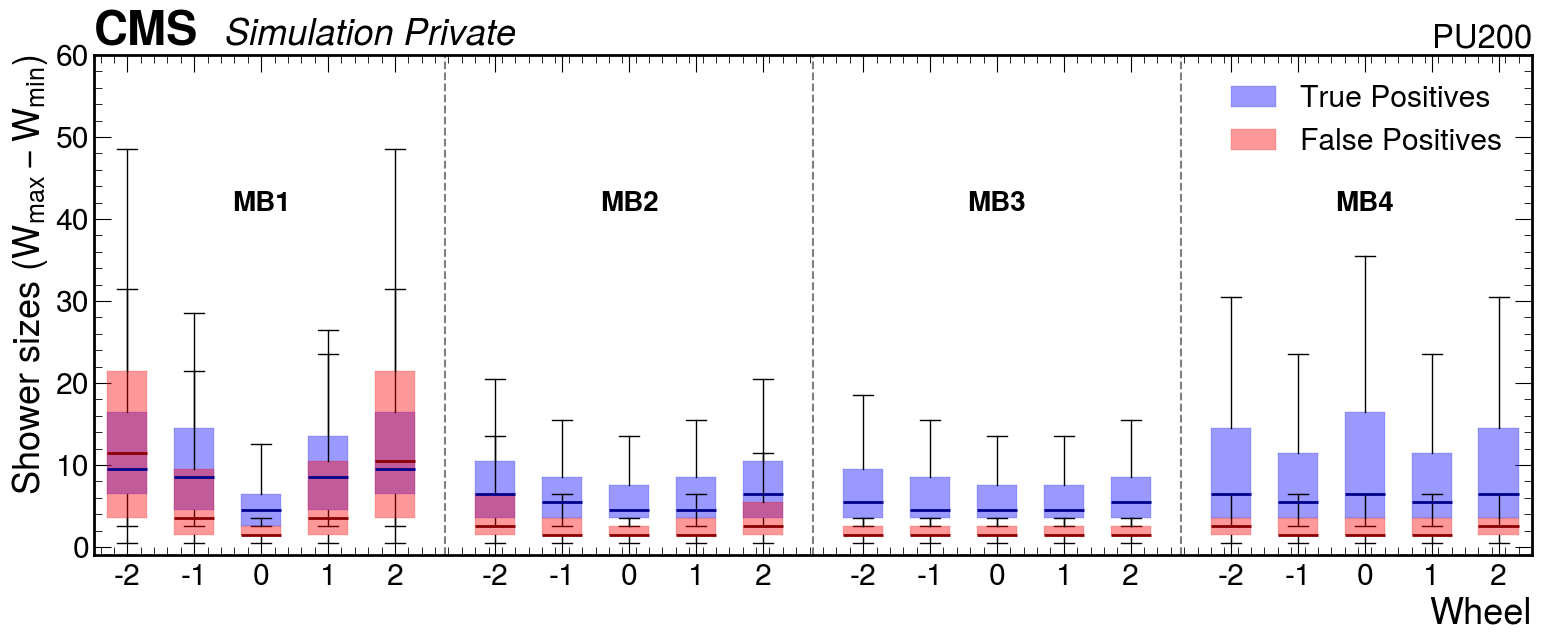

In [5]:
tp_data = []
fp_data = []
tick_positions = []
tick_labels = []

# 1. Collect data
current_pos = 0
for st in stations:
    for wh in wheels:
        key_tp = f"showers_size_{wh}_{st}_tp_method1;1"
        key_fp = f"showers_size_{wh}_{st}_fp_method1;1"
        
        def get_raw(key):
            if key in histos_zp_G:
                h = histos_zp_G[key].to_hist()
                return np.repeat(h.axes[0].centers, h.values().astype(int))
            return np.array([])

        tp_data.append(get_raw(key_tp))
        fp_data.append(get_raw(key_fp))
        
        tick_positions.append(current_pos)
        tick_labels.append(f"{wh}")
        current_pos += 1
    current_pos += 0.5 

# 2. Plotting
fig, ax = plt.subplots(figsize=(16, 7))

# Plot TP (Blue) and FP (Red) on the exact same positions
# Using alpha=0.5 so the overlap is visible
tp_boxes = ax.boxplot(tp_data, positions=tick_positions, widths=0.6, 
                      patch_artist=True, showfliers=False, label="True Positives")
fp_boxes = ax.boxplot(fp_data, positions=tick_positions, widths=0.6, 
                      patch_artist=True, showfliers=False, label="False Positives")

# 3. Styling - Overlapping with Alpha
for box in tp_boxes['boxes']:
    box.set(facecolor="blue", alpha=0.4, edgecolor="b", linewidth=0.3)
for box in fp_boxes['boxes']:
    box.set(facecolor="red", alpha=0.4, edgecolor="r", linewidth=0.3)

# Keep medians solid so they stand out through the alpha
plt.setp(tp_boxes['medians'], color='darkblue', lw=2)
plt.setp(fp_boxes['medians'], color='darkred', lw=2)

# 4. Axes, Labels and CMS style
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("Shower sizes (" + r"$W_{\text{max}} - W_{\text{min}}$" + ")")
ax.set_xlabel("Wheel")
ax.set_ylim(-1, 60)

# Station Labels
for i, st in enumerate(stations):
    center = (i * 5.5) + 2
    ax.text(center, ax.get_ylim()[0] + (ax.get_ylim()[1]*0.7), f"MB{st}", 
            ha='center', fontsize=20, fontweight='bold')
    if i < len(stations) - 1:
        ax.axvline((i * 5.5) + 4.75, color="black", linestyle="--", alpha=0.5)

ax.legend(loc='upper right') #handles=legend_elements, 

hep.cms.label(ax=ax, text="Private", data=False, rlabel="PU200")
plt.tight_layout()
plt.show()

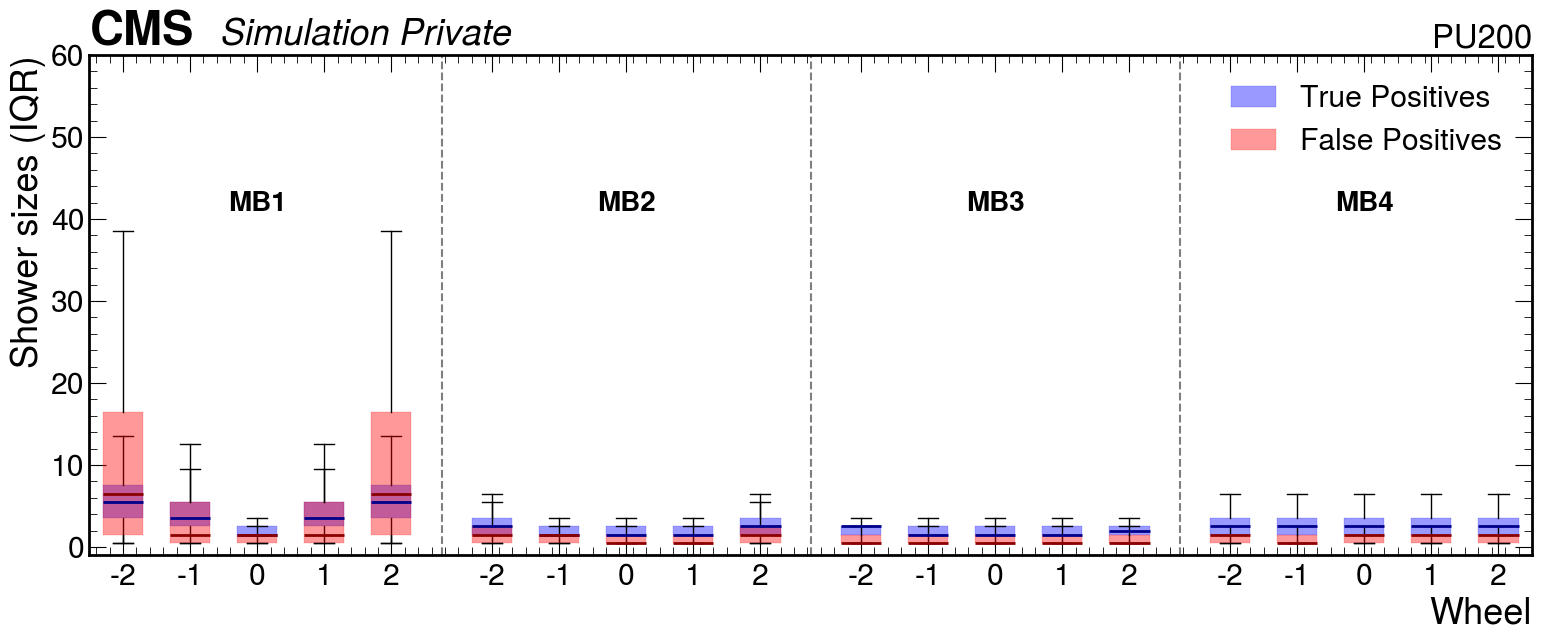

In [5]:
tp_data = []
fp_data = []
tick_positions = []
tick_labels = []

# 1. Collect data
current_pos = 0
for st in stations:
    for wh in wheels:
        key_tp = f"showers_size_{wh}_{st}_tp_method2;1"
        key_fp = f"showers_size_{wh}_{st}_fp_method2;1"
        
        def get_raw(key):
            if key in histos_zp_G:
                h = histos_zp_G[key].to_hist()
                return np.repeat(h.axes[0].centers, h.values().astype(int))
            return np.array([])

        tp_data.append(get_raw(key_tp))
        fp_data.append(get_raw(key_fp))
        
        tick_positions.append(current_pos)
        tick_labels.append(f"{wh}")
        current_pos += 1
    current_pos += 0.5 

# 2. Plotting
fig, ax = plt.subplots(figsize=(16, 7))

# Plot TP (Blue) and FP (Red) on the exact same positions
# Using alpha=0.5 so the overlap is visible
tp_boxes = ax.boxplot(tp_data, positions=tick_positions, widths=0.6, 
                      patch_artist=True, showfliers=False, label="True Positives")
fp_boxes = ax.boxplot(fp_data, positions=tick_positions, widths=0.6, 
                      patch_artist=True, showfliers=False, label="False Positives")

# 3. Styling - Overlapping with Alpha
for box in tp_boxes['boxes']:
    box.set(facecolor="blue", alpha=0.4, edgecolor="b", linewidth=0.3)
for box in fp_boxes['boxes']:
    box.set(facecolor="red", alpha=0.4, edgecolor="r", linewidth=0.3)

# Keep medians solid so they stand out through the alpha
plt.setp(tp_boxes['medians'], color='darkblue', lw=2)
plt.setp(fp_boxes['medians'], color='darkred', lw=2)

# 4. Axes, Labels and CMS style
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("Shower sizes (IQR)")
ax.set_xlabel("Wheel")
ax.set_ylim(-1, 60)

# Station Labels
for i, st in enumerate(stations):
    center = (i * 5.5) + 2
    ax.text(center, ax.get_ylim()[0] + (ax.get_ylim()[1]*0.7), f"MB{st}", 
            ha='center', fontsize=20, fontweight='bold')
    if i < len(stations) - 1:
        ax.axvline((i * 5.5) + 4.75, color="black", linestyle="--", alpha=0.5)

ax.legend(loc='upper right') #handles=legend_elements, 

hep.cms.label(ax=ax, text="Private", data=False, rlabel="PU200")
plt.tight_layout()
plt.show()

[array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64)]


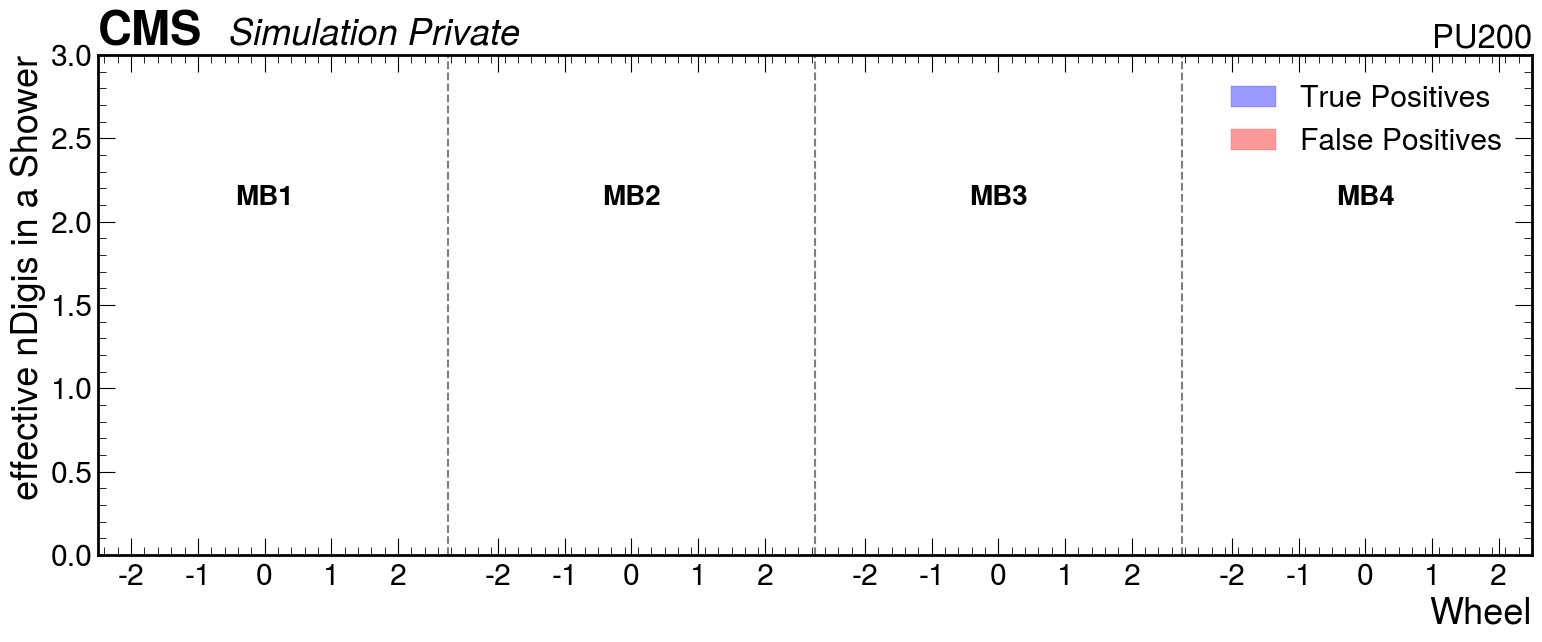

In [6]:
stations = [1, 2, 3, 4]
wheels = [-2, -1, 0, 1, 2]

tp_data = []
fp_data = []
tick_positions = []
tick_labels = []

# 1. Collect data
current_pos = 0
for st in stations:
    for wh in wheels:
        key_tp = f"nShowers_{wh}_{st}_tp;1"
        key_fp = f"nShowers_{wh}_{st}_fp;1"
        
        def get_raw(key):
            if key in histos_zp_G:
                h = histos_zp_G[key].to_hist()
                return np.repeat(h.axes[0].centers, h.values().astype(int))
            return np.array([])

        tp_data.append(get_raw(key_tp))
        fp_data.append(get_raw(key_fp))
        
        tick_positions.append(current_pos)
        tick_labels.append(f"{wh}")
        current_pos += 1
    current_pos += 0.5 

print(tp_data)
# 2. Plotting
fig, ax = plt.subplots(figsize=(16, 7))

# Plot TP (Blue) and FP (Red) on the exact same positions
# Using alpha=0.5 so the overlap is visible
tp_boxes = ax.boxplot(tp_data, positions=tick_positions, widths=0.6, 
                      patch_artist=True, showfliers=False, label="True Positives")
fp_boxes = ax.boxplot(fp_data, positions=tick_positions, widths=0.6, 
                      patch_artist=True, showfliers=False, label="False Positives")

# 3. Styling - Overlapping with Alpha
for box in tp_boxes['boxes']:
    box.set(facecolor="blue", alpha=0.4, edgecolor="b", linewidth=0.3)
for box in fp_boxes['boxes']:
    box.set(facecolor="red", alpha=0.4, edgecolor="r", linewidth=0.3)

# Keep medians solid so they stand out through the alpha
plt.setp(tp_boxes['medians'], color='darkblue', lw=2)
plt.setp(fp_boxes['medians'], color='darkred', lw=2)

# 4. Axes, Labels and CMS style
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("effective nDigis in a Shower")
ax.set_xlabel("Wheel")
ax.set_ylim(0, 3)

# Station Labels
for i, st in enumerate(stations):
    center = (i * 5.5) + 2
    ax.text(center, ax.get_ylim()[0] + (ax.get_ylim()[1]*0.7), f"MB{st}", 
            ha='center', fontsize=20, fontweight='bold')
    if i < len(stations) - 1:
        ax.axvline((i * 5.5) + 4.75, color="black", linestyle="--", alpha=0.5)

ax.legend(loc='upper right') #handles=legend_elements, 

hep.cms.label(ax=ax, text="Private", data=False, rlabel="PU200")
plt.tight_layout()
plt.show()